# Aprendizado Não Supervisionado

Nesta seção, usamos dois modelos de aprendizado não supervisionado para prever a probabilidade de inadimplência a medio prazo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, KFold

In [49]:
CAMINHO_BASE = '../final_data/'
TRAIN_DATASET = 'treino.csv'
TEST_DATASET =  'teste.csv'


df_tr = pd.read_csv(CAMINHO_BASE + TRAIN_DATASET) # dados de treino
df_te = pd.read_csv(CAMINHO_BASE + TEST_DATASET) # dados de teste
df = pd.concat([df_tr, df_te], ignore_index=True)

## 1. Isolation Florest



O Isolation Forest é um algoritmo usado para detectar anomalias com base no isolamento de observações. Ele faz isso escolhendo aleatoriamente uma variável para separar os dados em cada nó. O número de divisões necessárias para isolar uma observação corresponde ao comprimento do caminho da raiz até o nó final. Ao calcular esse comprimento médio em várias árvores aleatórias, o algoritmo obtém uma medida de “anormalidade”: observações que exigem menos divisões para serem isoladas são mais prováveis de serem anômalas.

Iremos encontrar o melhor hiperparâmetro (número de árvores) com o conjunto de treino. Posteriormente, iremos usar o Isolation Forest no conjunto de teste para obter uma score de anormalidade. Essa score será padronizada para o intervalo [0,1], sendo valores de scores indicando maior anormalidade mapeadas para próximo de 1.

Em seguida, usaremos essa score normalizada como mediada de probabilidade de inadimplência. Na penúltima subseção da seção sobre Isolation Forest, são feitas comparações entre essa métrica e as probabilidades do conjunto de treino.

### Seleção de hiperparâmetro

Devemos escolher o número de árvores a serem implementadas pelo modelo. Esse número é dado pelo parâmetro "n_estimators". Para escolhê-lo, testamos vários valores sequencialmente. Iniciamos com 5 árvores e aumentamos a cada iteração. A cada iteração, treinamos um modelo de Isolation Forest e obtemos um vetor com os scores de anomalia. Caculamos a correlação de Pearson desse vetor com o vetor obtido na iteração anterior. Desse modo, temos uma medida do quanto a resposta do nosso modelo varia com o aumento do hiperparâmetro. Espera-se que a correlação se torne alta a medida que "n_estimators" aumente.

In [50]:
# # remove coluna alvo
coluna_alvo = 'SeriousDlqin2yrs'
X_train = df_tr.drop(columns=[coluna_alvo]).select_dtypes(include=np.number)

# lista de valores a serem testados
n_estimators_list = [5, 10, 20, 40, 60, 100, 150, 175, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700]
correlations = []

ant_anomaly_scores = None
# testa todos os valores
for i, n in enumerate(n_estimators_list):
    iso_forest = IsolationForest(n_estimators=n, contamination='auto', random_state=42) # cria modelo com n árvores
    iso_forest.fit(X_train) # treina modelo

    # calcula anomaly score
    df_tr_scores = pd.DataFrame({
        'anomaly_score': iso_forest.decision_function(X_train)
    })
    anomaly_scores = df_tr_scores['anomaly_score'].values.reshape(-1, 1)

    # calcula correlação com valores anteriores
    if i > 0:
        corr, _ = pearsonr(anomaly_scores, ant_anomaly_scores)
        correlations.append(corr)
        print(f"n_estimators: {n}, corr (Pearson): {corr[0]}")

    ant_anomaly_scores = anomaly_scores

n_estimators: 10, corr (Pearson): 0.9351753612232347
n_estimators: 20, corr (Pearson): 0.9416299949580317
n_estimators: 40, corr (Pearson): 0.9589204405318825
n_estimators: 60, corr (Pearson): 0.9868055947768837
n_estimators: 100, corr (Pearson): 0.9918048849773626
n_estimators: 150, corr (Pearson): 0.9958145030186518
n_estimators: 175, corr (Pearson): 0.9987626318974795
n_estimators: 200, corr (Pearson): 0.9990483893690708
n_estimators: 250, corr (Pearson): 0.9988784830095156
n_estimators: 300, corr (Pearson): 0.9992841184960425
n_estimators: 350, corr (Pearson): 0.9994420847797603
n_estimators: 400, corr (Pearson): 0.9995663451252504
n_estimators: 450, corr (Pearson): 0.9997198619629564
n_estimators: 500, corr (Pearson): 0.9996203635167916
n_estimators: 550, corr (Pearson): 0.9997123430742592
n_estimators: 600, corr (Pearson): 0.9998039016803
n_estimators: 650, corr (Pearson): 0.9998414550217165
n_estimators: 700, corr (Pearson): 0.9998791859716308


Os valores obtidos podem ser visualizados abaixo:

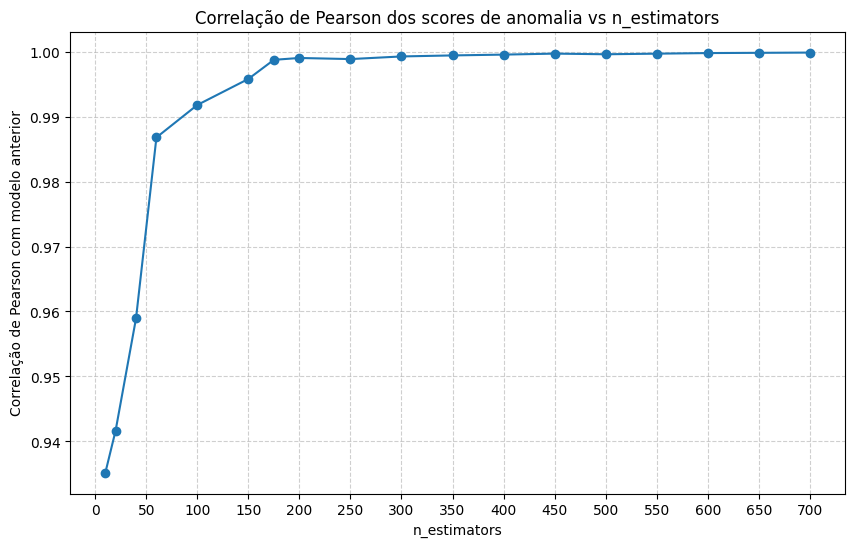

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list[1:], correlations, marker='o', linestyle='-')
plt.title('Correlação de Pearson dos scores de anomalia vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Correlação de Pearson com modelo anterior')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, max(n_estimators_list) + 50, 50))
plt.show()

Note que para n_estimators = 175 a correlação de Pearson com os dados anteriores é muito alta: 0.9991684794918286 \
Isso pode indicar que não há diferença significativa ao aumentar o n_estimators. \
Portanto, escolhemos o n_estimators anterior: 150 (valor bastante razoável).

In [52]:
N_ESTIMATORS=150

### Distribuição de score de anomalidade normalizado para cada uma das classes

Criamos o modelo com n_estimators=150:

In [53]:
if_model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination='auto',
    random_state=42
)

if_model.fit(X_train)

,n_estimators,150
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


Criamos um novo dataset contendo apenas o score de anomalia de cada registro do conjunto de treino como coluna:

In [54]:
df_tr_scores = pd.DataFrame({
    'anomaly_score': if_model.decision_function(X_train)
})

df_tr_scores.head()

,anomaly_score
0,-0.012772
1,0.122484
2,0.058436
3,0.142494
4,-0.025082


Normalizamos o score de anomalia, isto é, escalamos o score para o intervalo (0, 1). \
Após isso, adicionamos o score de anomalia normalizado como uma nova coluna ao dataset "df_tr_scores":

In [55]:
# função de normalização
def normalize_scores(anomaly_scores):
    scaler = MinMaxScaler(feature_range=(0, 1))
    normalized_scores = scaler.fit_transform(anomaly_scores).flatten()
    inverted_anomaly_score = 1 - normalized_scores
    return inverted_anomaly_score


# criação da coluna de score de anomalia normalizado
anomaly_scores = df_tr_scores['anomaly_score'].values.reshape(-1, 1)
df_tr_scores['normalized_anomaly_score'] = normalize_scores(anomaly_scores)

df_tr_scores.head()


,anomaly_score,normalized_anomaly_score
0,-0.012772,0.407156
1,0.122484,0.087550
2,0.058436,0.238895
3,0.142494,0.040267
4,-0.025082,0.436246


Seria interessante entender como o score de anomalia normalizado está distribuido em cada uma das classes (entre adimplentes e inadimplentes). Para tanto, visualizaremos as distribuições em cada classe.

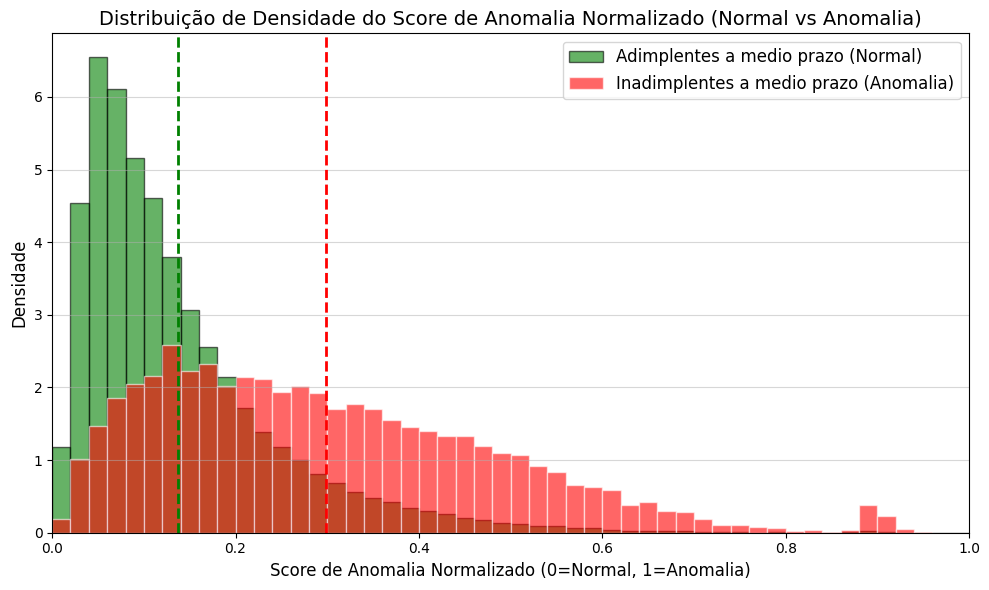

In [56]:
# extrair as séries de scores de cada classe
anomalia_scores = df_tr_scores.loc[df_tr['SeriousDlqin2yrs'] == 1, 'normalized_anomaly_score']
normal_scores   = df_tr_scores.loc[df_tr['SeriousDlqin2yrs'] == 0, 'normalized_anomaly_score']

# calcular as médias
mean_anomalia = anomalia_scores.mean()
mean_normal = normal_scores.mean()

# definir o range completo do score normalizado
hist_range = (0, 1)

# configurar e plotar o histograma Sobreposto
plt.figure(figsize=(10, 6))

# histograma da Classe NORMAL (SeriousDlqin2yrs == 0)
plt.hist(
    normal_scores,
    bins=50,
    alpha=0.6,
    label='Adimplentes a medio prazo (Normal)',
    range=hist_range,
    density=True,
    color='green',
    edgecolor='black'
)

# histograma da Classe ANÔMALA (SeriousDlqin2yrs == 1)
plt.hist(
    anomalia_scores,
    bins=50,
    alpha=0.6,
    label='Inadimplentes a medio prazo (Anomalia)',
    range=hist_range,
    density=True,
    color='red',
    edgecolor='white'
)

plt.legend(fontsize=12)
plt.title("Distribuição de Densidade do Score de Anomalia Normalizado (Normal vs Anomalia)", fontsize=14)
plt.xlabel("Score de Anomalia Normalizado (0=Normal, 1=Anomalia)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)

# adicionar linhas verticais para as médias
plt.axvline(mean_normal, color='green', linestyle='dashed', linewidth=2, label='Média Normal')
plt.axvline(mean_anomalia, color='red', linestyle='dashed', linewidth=2, label='Média Anomalia')
plt.grid(axis='y', alpha=0.5)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Nota-se na visualização acima uma diferença significativa nas distribuições em cada classe. Isso pode significar que o score de anomalia é uma boa medida para explicar a inadimplência de longo prazo.

### Usando score de anomalia normalizado como probabilidade de inadimplência a medio prazo

Usaremos o modelo já treinado anteriormente para comparar o score de anormalidade obtidos com a probabilidade de inadimplência a medio prazo.

Para isso, calcularemos o score anormalidade e o normalizaremos, desta vez para o conjunto de teste.

In [57]:
# remove a coluna alvo dos dados de teste
coluna_alvo = 'SeriousDlqin2yrs'
X_test = df_te.drop(columns=[coluna_alvo]).select_dtypes(include=np.number)

# cria um dataset dos scores para o conjunto de teste
df_te_scores = pd.DataFrame({
    'anomaly_score': if_model.decision_function(X_test)
})

# criação da coluna de score de anomalia normalizado
anomaly_scores = df_te_scores['anomaly_score'].values.reshape(-1, 1)
df_te_scores['normalized_anomaly_score'] = normalize_scores(anomaly_scores)

df_te_scores.head()


,anomaly_score,normalized_anomaly_score
0,0.128881,0.076886
1,0.052731,0.264168
2,0.128577,0.077634
3,0.110331,0.122507
4,0.108860,0.126125


Em seguida, podemos visualizar a distribuição do Score de Anomalia Normalizado no conjunto de teste:

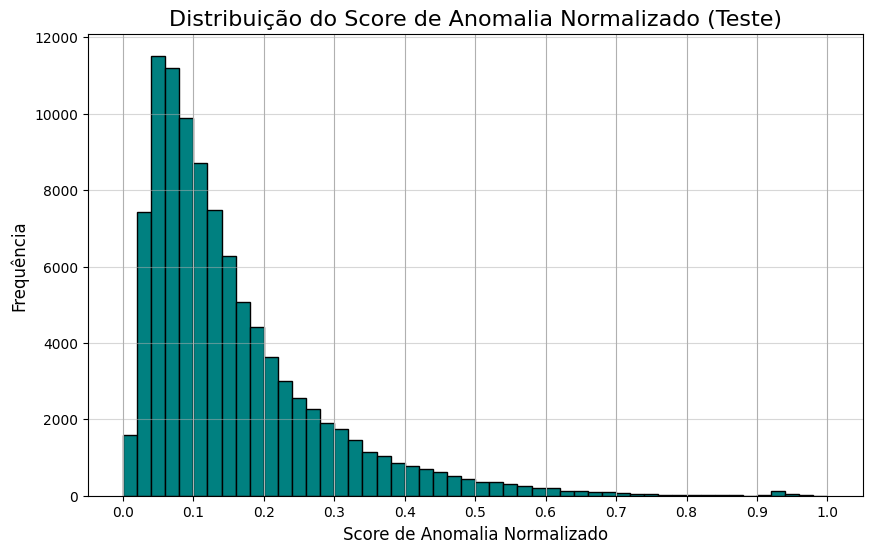

In [58]:
plt.figure(figsize=(10, 6))

df_te_scores['normalized_anomaly_score'].hist(
    bins=50,
    edgecolor='black',
    color='teal'
)

plt.title('Distribuição do Score de Anomalia Normalizado (Teste)', fontsize=16)
plt.xlabel('Score de Anomalia Normalizado', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.show()

A maioria dos registros possuem baixa anomalia como esperado.

### Comparação

Em seguida, calculamos a média das diferenças entre o score de anomalia normalizado e a inadimplência a medio prazo (variável alvo)

In [59]:
df_te_scores['absolute_difference'] = np.abs(df_te_scores['normalized_anomaly_score'] - df_te['SeriousDlqin2yrs'])
df_te_scores["difference"] = df_te_scores['normalized_anomaly_score'] - df_te['SeriousDlqin2yrs']


print(f"Média dos Módulos das Diferenças: {df_te_scores['absolute_difference'].mean():.4f}")
print(f"Média das Diferenças: {df_te_scores['difference'].mean():.4f}")

Média dos Módulos das Diferenças: 0.0942
Média das Diferenças: 0.0879


A média das diferenças é pequena. Ótimo!

Agora, podemos visualizar a dsitribuição absoluta da diferença entre o Score de Anomalia Normalizado e a Probabilidade de Inadimplência (a medio prazo).

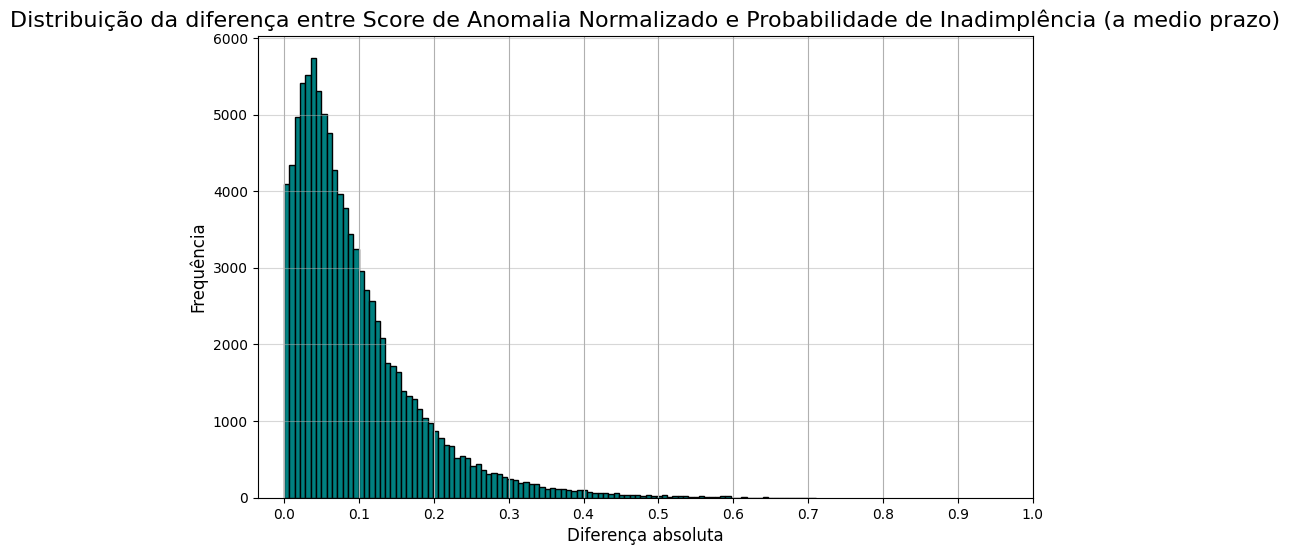

In [60]:
plt.figure(figsize=(10, 6))

df_te_scores['absolute_difference'].hist(
    bins=100,
    edgecolor='black',
    color='teal',
)

plt.title('Distribuição da diferença entre Score de Anomalia Normalizado e Probabilidade de Inadimplência (a medio prazo)', fontsize=16)
plt.xlabel('Diferença absoluta', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

A diferença se concentra muito próxima de 0.

A seguir, exploraremos um pouco mais a distribuição do erro absoluto da previsão.

Podemos visualizar o boxplot do erro absoluto.

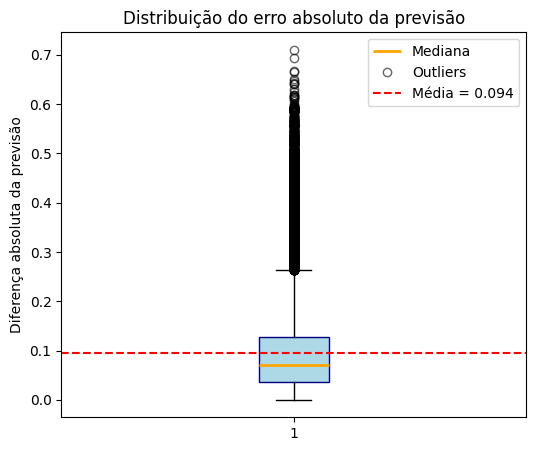

In [61]:
# cria bloxplot
plt.figure(figsize=(6, 5))
plt.boxplot(
    df_te_scores['absolute_difference'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='orange', linewidth=2, label='Mediana'),
    flierprops=dict(marker='o', color='black', alpha=0.6, label='Outliers')
)
plt.title('Distribuição do erro absoluto da previsão')
plt.ylabel('Diferença absoluta da previsão')

# linha da média
plt.axhline(df_te_scores['absolute_difference'].mean(), color='red', linestyle='--', label=f'Média = {df_te_scores['absolute_difference'].mean():.3f}')
plt.legend()

plt.show()

Aqui estão algumas informações relevantes sobre a distribuição:

In [62]:
print("\n📊 Informações sobre o Erro Absoluto")
print("-" * 40)

print("\nmínimo:", df_te_scores['absolute_difference'].min())
print("\nmáximo:", df_te_scores['absolute_difference'].max())
print("\nquantis: \n", df_te_scores['absolute_difference'].quantile([0.25, 0.5, 0.75, 0.9]))
print("\nmédia:", df_te_scores['absolute_difference'].mean())
print("\ndesvio padrão:", df_te_scores['absolute_difference'].std())


📊 Informações sobre o Erro Absoluto
----------------------------------------

mínimo: 1.3704814224718698e-06

máximo: 0.710354813582818

quantis: 
 0.25    0.035989
0.50    0.071045
0.75    0.127139
0.90    0.200627
Name: absolute_difference, dtype: float64

média: 0.09417453696841052

desvio padrão: 0.08284448220567768


Em 75% dos casos, a diferença entre o score de anomalia normalizado e a probabilidade real de inadimplência a medio prazo é menor que 0,13.

### Usando o Score de Anomalia Normalizado como proxy para a Probabilidade de Inadimplência

Com base nas observações acima, o Score de Anomalia Normalizado parece um bom candidato para ser usado como uma proxy para a Probabilidade de Inadimplência. \
É o que faremos a seguir.

No conjunto de treino:

In [63]:
y_tr_pred = df_tr_scores['normalized_anomaly_score']

Abaixo, foram calculadas as métricas AUC-ROC e PR AUC no conjunto de treinamento apenas como referência. Embora o modelo seja não supervisionado, essas métricas permitem avaliar a capacidade do score de anomalia em distinguir observações rotuladas como positivas e negativas, sem que isso represente necessariamente sua capacidade de generalização.

In [64]:
y_true = df_tr['SeriousDlqin2yrs']

roc_auc = roc_auc_score(y_true, y_tr_pred)
pr_auc = average_precision_score(y_true, y_tr_pred)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR  AUC: {pr_auc:.4f}")

ROC AUC: 0.7860
PR  AUC: 0.2730


Agora, usando como proxy para a Probabilidade de Inadimplência no conjunto de teste.

In [65]:
y_te_pred = df_te_scores['normalized_anomaly_score']

Com isso, podemos calcular a performance do modelo em predizer as probabilidades no conjunto de teste

In [66]:
y_true = df_te['SeriousDlqin2yrs']

print("MSE:", mean_squared_error(y_true, y_te_pred))
print("MAE:", mean_absolute_error(y_true, y_te_pred))
print("Corr (Pearson):", y_true.corr(y_te_pred))

MSE: 0.015731982233567067
MAE: 0.09417453696841052
Corr (Pearson): 0.7273238049761606


### Resultados do Isolation Forest

Podemos observar pelos resultados que a score de anomalia funciona como uma proxy para a probabilidade de inadimplência a medio prazo. A correlação de pearson entre a as probabilidades do conjunto de teste e a score normalizada foi de 68%, enquanto o erro absoluto médio foi de 0,09. Além disso, em 75% dos casos, a diferença entre o score de anomalia normalizado e a probabilidade real de inadimplência a medio prazo é menor que 0,13.

## 2. GaussMixture

O Gaussian Mixture Model (GMM) é um modelo probabilístico que pressupõe que os dados observados são gerados a partir de número finito de distribuições Gaussianas. Ele usa o algoritmo Expectation-Maximization para estimar os parâmetros (médias, covariâncias) de cada componente Gaussiana, bem como as probabilidades de mistura ($\pi_k$), que representam o probabilidade de um ponto aleatório ter sido gerado pela distribuição k. O GMM não atribui um ponto a um único cluster como o k-menas, mas sim calcula a probabilidade a posteriori de que o ponto pertença a cada classe k (distribuição k).

Usaremos o gaussmixture para achar representações latentes a serem usadas em um modelo de regressão logística. Na penúltima subseção, serão comparadas as probabilidades previstas pelo modelo logístico com as probabilidades do conjunto de teste.

### Seleção de hiperparâmetros

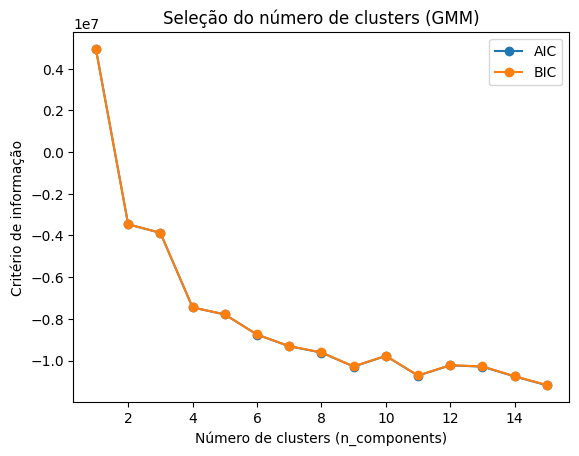

In [67]:
X_train = df.drop(columns=[coluna_alvo,]).select_dtypes(include=np.number)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

n_components_range = range(1, 16)
aic = []
bic = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=3
    )
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.xlabel('Número de clusters (n_components)')
plt.ylabel('Critério de informação')
plt.legend()
plt.title('Seleção do número de clusters (GMM)')
plt.show()


Pelos resultados da validação com critérios de informação AIC e BIC e com base no método do cotovelo, usaremos 7 distribuições gaussianas multivarivadas para o modelo.

### Ajuste do GaussMixture com 7 distribuições

Removemos a coluna alvo do dataframe.

In [68]:
coluna_alvo = 'SeriousDlqin2yrs'
X_train = df.drop(columns=[coluna_alvo,]).select_dtypes(include=np.number)

Criamos o modelo com 7 distribuições.

In [69]:
n_clusters = 7

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type='full', # Tipo de matriz de covariância ('full', 'tied', 'diag', 'spherical')
    random_state=42,
    n_init=5
)

Normalizamos os dados do conjunto de treino e treinamos o modelo nesses dados.

In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
gmm.fit(X_scaled)

,n_components,7
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,5
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


Então, podemos atribuir um rótulo de cluster a cada observação, calcular as probabilidades de pertencimento a cada cluster e registrar o log-likelihood individual

In [71]:
# Rótulos de Cluster
cluster_labels = gmm.predict(X_scaled)
df['gmm_cluster'] = cluster_labels

# Retorna a probabilidade de cada observação pertencer a cada um dos n_clusters
cluster_proba = gmm.predict_proba(X_scaled)

# Retorna o score de log-likelihood para cada observação
# Scores mais baixos indicam menor probabilidade de pertencer ao modelo
log_likelihood_scores = gmm.score_samples(X_scaled)
df['gmm_log_likelihood'] = log_likelihood_scores

Salvamos a probabilidade de pertencimento a cada um dos clusters

In [72]:
cols_proba = []
cluster_proba = gmm.predict_proba(X_scaled)
for i in range(n_clusters):
    df[f'proba_cluster_{i}'] = cluster_proba[:, i]
    cols_proba.append(f'proba_cluster_{i}')

Visualizaremos a proporção de adimplentes/inadimplentes a medio prazo em cada cluster.

In [73]:
df_b = df[(df['SeriousDlqin2yrs'] == 0) | (df['SeriousDlqin2yrs'] == 1)].copy()

contingency_table = pd.crosstab(
    df_b['gmm_cluster'],
    df_b['SeriousDlqin2yrs'],
    normalize='index'
)

contingency_table.columns = ['Proporção Adimplentes (Normal)', 'Proporção Inadimplentes (Anomalia)']
print("Proporção de Classes por Cluster GMM")
contingency_table.round(3)


Proporção de Classes por Cluster GMM


,Proporção Adimplentes (Normal),Proporção Inadimplentes (Anomalia)
gmm_cluster,,
0,0.620,0.380
1,0.433,0.567
2,0.653,0.347
3,0.955,0.045
4,0.906,0.094
5,0.901,0.099
6,0.971,0.029


Podemos visualizar essas distribuições.

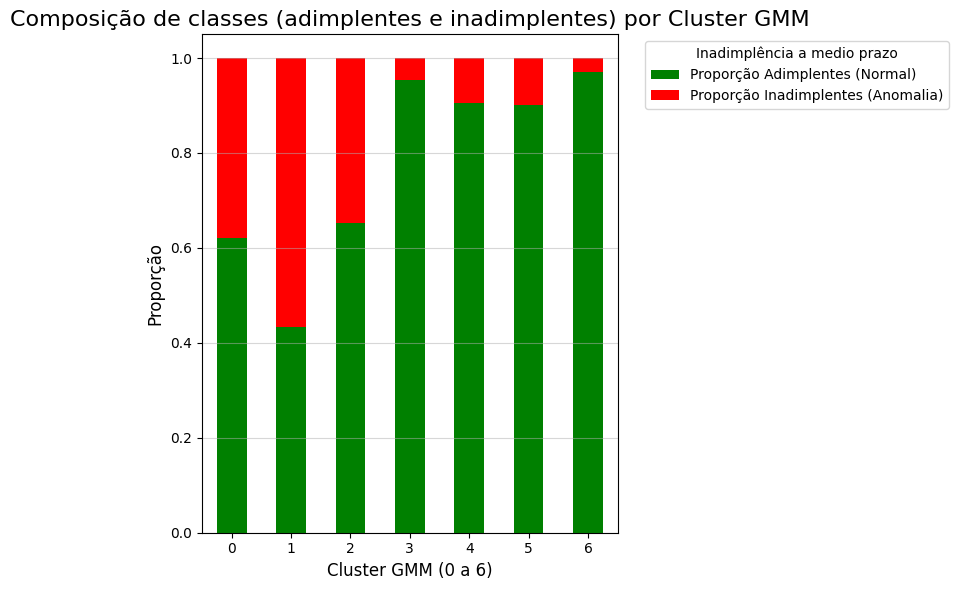

In [74]:
plt.figure(figsize=(10, 6))

contingency_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['green', 'red'],
    ax=plt.gca()
)

plt.title('Composição de classes (adimplentes e inadimplentes) por Cluster GMM', fontsize=16)
plt.xlabel('Cluster GMM (0 a 6)', fontsize=12)
plt.ylabel('Proporção', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Inadimplência a medio prazo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Podemos observar que os inadimplentes de médio prazo se concentram em três dos 7 clusters (são mais prováveis de serem da distribuições 0, 1 e 2).

#### Separação em treino e validação

In [75]:
X_train, X_val, y_train, y_val = train_test_split(
    df_b[cols_proba],
    df_b['SeriousDlqin2yrs'],
    test_size=0.1,
    random_state=42,
    stratify=df_b['SeriousDlqin2yrs']  # garante proporção das classes
)

#### Regressão Logística: avaliação, ajuste e predição

Agora, podemos representar cada registro com 7 features apenas: (probabilidade de pertencimento ao cluster 0, 2, 3, ..., 6).

Iremos treinar o modelo, então, avaliar o modelo em um conjunto de validação; por fim, iremos usar todos os dados para treinar o modelo final.

In [76]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


calculamos, então, o AUC ROC para avaliar o modelo. Primeiro com só uma divisão para visualizarmos a curva ROC. Em seguida, usando 5 folds para termos uma medida mais estável.  

In [77]:
y_pred_proba_logit = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_pred_proba_logit)
print(f"AUC na validação: {auc:.4f}")

AUC na validação: 0.7643


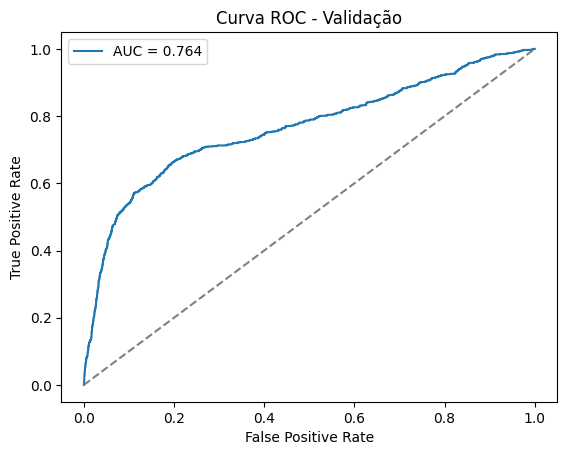

In [78]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_logit)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Validação')
plt.legend()
plt.show()

In [79]:
X = df_b[cols_proba]
y = df_b['SeriousDlqin2yrs']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for i, (train_index, val_index) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Treinar o modelo Logit
    logit_model = LogisticRegression()
    logit_model.fit(X_train, y_train)

    # Prever probabilidades
    y_pred_proba = logit_model.predict_proba(X_val)[:, 1]

    # Calcular AUC
    auc = roc_auc_score(y_val, y_pred_proba)
    auc_scores.append(auc)

    print(f"Fold {i+1}: AUC = {auc:.4f}")

# AUC médio e desvio padrão
print("\nMédia do AUC (5 folds): {:.4f}".format(np.mean(auc_scores)))
print("Desvio padrão do AUC: {:.4f}".format(np.std(auc_scores)))

Fold 1: AUC = 0.7611
Fold 2: AUC = 0.7708
Fold 3: AUC = 0.7693
Fold 4: AUC = 0.7617
Fold 5: AUC = 0.7601

Média do AUC (5 folds): 0.7646
Desvio padrão do AUC: 0.0045


Agora treinamos com todos os dados.

In [80]:
model = LogisticRegression()
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Podemos então, fazer a previsão da probabilidade de inadimplência a médio prazo.

In [81]:
df_t = df[(df['SeriousDlqin2yrs'] != 0) & (df['SeriousDlqin2yrs'] != 1)].copy()
predicted_p_test = model.predict_proba(df_t[cols_proba])
df_t["predicted_proba_logit"] = predicted_p_test[:, 1]

#### Comparação da probabilidade prevista com a real

Calculemos a média dos módulos das diferenças entre a probabilidade prevista e a probilidade de inadimplência a médio prazo (variável alvo).

In [82]:
abs_diff = np.abs(df_t["predicted_proba_logit"] - df_t['SeriousDlqin2yrs'])
df_t["abs_diff"] = abs_diff
print(f"Média dos Módulos das Diferenças: {df_t['abs_diff'].mean():.4f}")

Média dos Módulos das Diferenças: 0.0388


A média da diferença é 0.0388, bastante baixa. Ótimo!

Visualizaremos a seguir a distribuição dos módulos das diferenças.

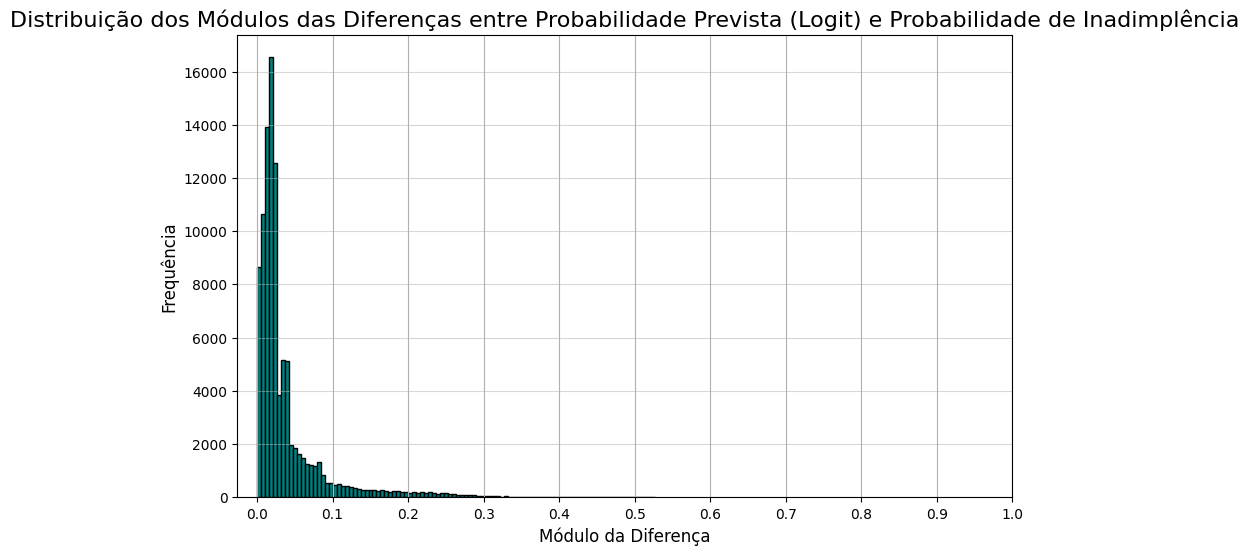

In [83]:
plt.figure(figsize=(10, 6))
df_t['abs_diff'].hist(
    bins=100,
    edgecolor='black',
    color='teal'
)
plt.title('Distribuição dos Módulos das Diferenças entre Probabilidade Prevista (Logit) e Probabilidade de Inadimplência', fontsize=16)
plt.xlabel('Módulo da Diferença', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Como esperado, se concentram perto de 0.

Estimemos a performance do modelo:

In [84]:
# métricas
y_true = df_t['SeriousDlqin2yrs']
y_pred = df_t['predicted_proba_logit']

print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("Corr (Pearson):", y_true.corr(y_pred))

MSE: 0.00415561061896597
MAE: 0.03877994745195078
Corr (Pearson): 0.8133377549653091


A seguir, exploraremos um pouco mais a distribuição do erro absoluto da previsão (Logit).

In [85]:
print("\n📊 Informações sobre o Erro Absoluto")
print("-" * 40)


print("\nmínimo:", df_t['abs_diff'].min())
print("\nmáximo:", df_t['abs_diff'].max())
print("\nquantis: \n", df_t['abs_diff'].quantile([0.25, 0.5, 0.75, 0.9]))
print("\nmédia:", df_t['abs_diff'].mean())
print("\ndesvio padrão:", df_t['abs_diff'].std())


📊 Informações sobre o Erro Absoluto
----------------------------------------

mínimo: 2.939988002458038e-07

máximo: 0.5270062066243483

quantis: 
 0.25    0.012813
0.50    0.020983
0.75    0.039357
0.90    0.087911
Name: abs_diff, dtype: float64

média: 0.03877994745195078

desvio padrão: 0.05149517563126761


#### Probit: ajuste e regressão

A seguir usaremos Probit para fazer o mesmo processo de regressão.
Abaixo, treinamos o modelo:

In [86]:
probit_model = sm.Probit(y_train, X_train)
result = probit_model.fit()

Optimization terminated successfully.
         Current function value: 0.203817
         Iterations 7


Em seguida, visualização o desempenho do modelo no conjunto de validação. Primeiro com só uma divisão para visualizarmos a curva ROC. Em seguida, usando 5 folds para termos uma medida mais estável.

AUC (Probit) na validação: 0.7602


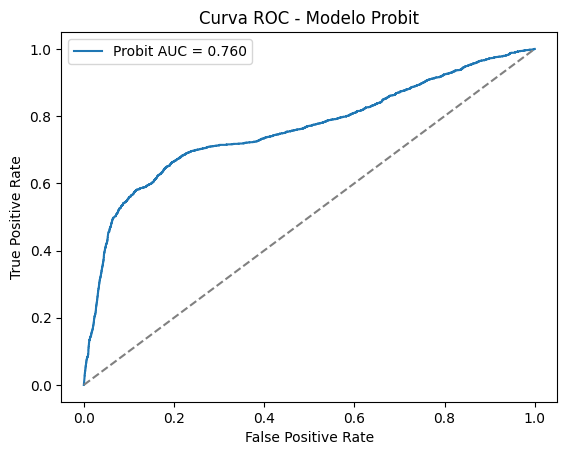

In [87]:
y_pred_proba_probit = result.predict(X_val)

auc = roc_auc_score(y_val, y_pred_proba_probit)
print(f"AUC (Probit) na validação: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_probit)
plt.plot(fpr, tpr, label=f'Probit AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo Probit')
plt.legend()
plt.show()

In [88]:
X = df_b[cols_proba]
y = df_b['SeriousDlqin2yrs']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for i, (train_index, val_index) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Treinar o modelo Probit
    probit_model = sm.Probit(y_train, X_train)
    result = probit_model.fit(disp=False)

    # Prever probabilidades
    y_pred_proba = result.predict(X_val)

    # Calcular AUC
    auc = roc_auc_score(y_val, y_pred_proba)
    auc_scores.append(auc)

    print(f"Fold {i+1}: AUC = {auc:.4f}")

# AUC médio e desvio padrão
print("\nMédia do AUC (5 folds): {:.4f}".format(np.mean(auc_scores)))
print("Desvio padrão do AUC: {:.4f}".format(np.std(auc_scores)))

Fold 1: AUC = 0.7612
Fold 2: AUC = 0.7712
Fold 3: AUC = 0.7694
Fold 4: AUC = 0.7618
Fold 5: AUC = 0.7602

Média do AUC (5 folds): 0.7648
Desvio padrão do AUC: 0.0046


Agora treinamos com todos os dados.

In [89]:
probit_model = sm.Probit(y, X)
result = probit_model.fit()

Optimization terminated successfully.
         Current function value: 0.204232
         Iterations 7


Podemos então, fazer a previsão da probabilidade de inadimplência a médio prazo.

In [90]:

X_test = df_t[cols_proba]

predicted_p_test = result.predict(X_test)
df_t["predicted_proba_Probit"] = predicted_p_test
df_t["difference_probit"] = df_t["predicted_proba_Probit"] - df_t['SeriousDlqin2yrs']
df_t["abs_difference_probit"] = np.abs(df_t["difference_probit"])

#### Comparação da probabilidade prevista com a real

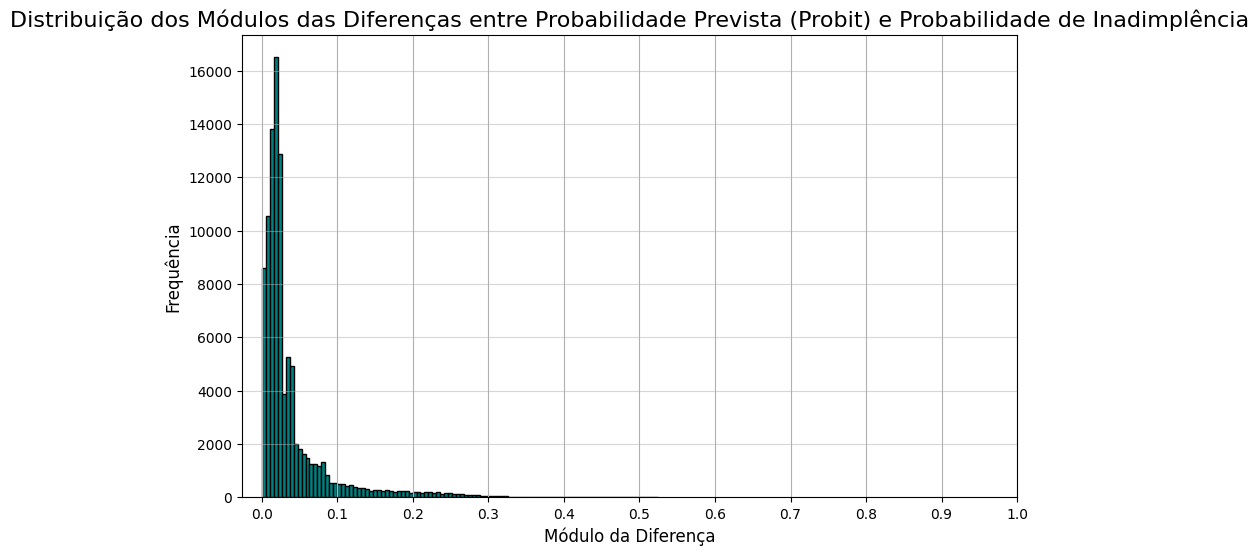

In [91]:
plt.figure(figsize=(10, 6))
df_t['abs_difference_probit'].hist(
    bins=100,
    edgecolor='black',
    color='teal'
)
plt.title('Distribuição dos Módulos das Diferenças entre Probabilidade Prevista (Probit) e Probabilidade de Inadimplência', fontsize=16)
plt.xlabel('Módulo da Diferença', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

E podemos calcular a performance do modelo com as mesmas métricas usadas anteriormente.

In [92]:
y_true = df_t['SeriousDlqin2yrs']
y_pred = df_t['predicted_proba_Probit']

print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("Corr (Pearson):", y_true.corr(y_pred))

MSE: 0.004154626541392205
MAE: 0.03875910603218479
Corr (Pearson): 0.8135272131181477


A seguir, exploraremos um pouco mais a distribuição do erro absoluto da previsão (Probit).

In [93]:
print("\n📊 Informações sobre o Erro Absoluto")
print("-" * 40)

print("\nmínimo:", df_t['abs_difference_probit'].min())
print("\nmáximo:", df_t['abs_difference_probit'].max())
print("\nquantis: \n", df_t['abs_difference_probit'].quantile([0.25, 0.5, 0.75, 0.9]))
print("\nmédia:", df_t['abs_difference_probit'].mean())
print("\ndesvio padrão:", df_t['abs_difference_probit'].std())


📊 Informações sobre o Erro Absoluto
----------------------------------------

mínimo: 1.374077830216397e-06

máximo: 0.5250464086906195

quantis: 
 0.25    0.012819
0.50    0.020997
0.75    0.039106
0.90    0.088042
Name: abs_difference_probit, dtype: float64

média: 0.03875910603218479

desvio padrão: 0.05150131130441783


### Resultados

Podemos observar pelos resultados das regressões, treinadas com as representações latentes, que há grupos de pessoas nos dados e as informações sobre as probabilidades de pertencimento são capazes de gerar uma representação reduzida (apenas 4 colunas) e informativa.

Para a probit, a correlação de pearson entre as probabilidades
foi de 0.80, enquanto o MAE foi de 0.04. Além disso, para 75% dos dados, a probabilidade estimada está distante menos de 0,095 da probabilidade de inadimplência a medio prazo no conjunto de teste.

Para a logit, os resultados deram muito parecidos (diferem nas últimas casas decimais), a correlação de pearson entre as probabilidades
foi de 0.80, enquanto o MAE foi de 0.04. Além disso, para 90% dos dados, a probabilidade estimada está distante menos de 0,095 da probabilidade de inadimplência a medio prazo no conjunto de teste.

## 3. Resultados finais

A seguir, comparamos todos os modelos pela sua performance. \
Obs.: Também treinamos o Gaussian Mixture com 4 classes e a performance obtida está na tabela abaixo.

### 📊 Desempenho (modelo vs. modelo)

| Modelo                   | MSE        | MAE        | Correlação (Pearson) | AUC ROC (val) |
|---------------------------|------------|------------|-----------------------|------------------|
| **Isolation Forest**      | 0.015732   | 0.094175   | 0.727324              | **0.7860** |
| **GaussMixture(7) + Logit**  | **0.004156** | 0.038780   | 0.813338              | 0.7646 |
| **GaussMixture(7) + Probit** | 0.004155   | **0.038759** | **0.813527**          | 0.7648 |
| **GaussMixture(4) + Logit**            | 0.004460     | 0.040390     | 0.797694          | 0.7640 |
| **GaussMixture(4) + Probit**           | 0.004461     | 0.040379 | 0.797665              | 0.7640 |


- Os modelos Logit e Probit apresentaram desempenhos praticamente idênticos, com menores erros médios (MSE e MAE) e maior correlação entre as probabilidades previstas e os valores reais.
- O Isolation Forest, por sua vez, exibiu erros mais elevados — comportamento esperado, uma vez que se trata de um método não supervisionado, que não utiliza os rótulos verdadeiros durante o treinamento. Ainda assim, seu desempenho é satisfatório ao capturar parte relevante da estrutura dos dados.

Considerando desempenho, tanto o modelo Logit quanto o Probit se mostram as melhores escolha para aplicações práticas e previsão de inadimplência. Apesar de Logit e Probit serem modelos lineares, as variáveis que eles interepretam (do GaussMixture) não têm significado no espaço original dos dados. \
Já o Isolation Forest apresenta uma interpretabilidade razoável e pode ser escolhido por esse motivo. Podento também ser mantido como ferramenta complementar de detecção preliminar de anomalias.